In [1]:
pip install matplotlib-scalebar

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process import kernels
from sklearn.gaussian_process.kernels import ( ConstantKernel, RBF, WhiteKernel, Matern)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_squared_error,  mean_absolute_error, r2_score)
from matplotlib_scalebar.scalebar import ScaleBar

In [3]:
#variables
var = gpd.read_file("/content/drive/MyDrive/Universidad/POSGRADO/Analisis Geoespacial/Datos/AREAS/Barrios_var.gpkg", layer="variables")
var.head()

,nombre_bar,nombre_com,Shape_Leng,Shape_Area,Movimientos,Area_km2,Densidad,Porc_area,Porc_mov,I_concentracion,Pend_mean,Porc_Artificial,Porc_Qca,Porc_TPu,geometry
0,Aguas Frias,ALTAVISTA,32888.553485,1.308501e+07,27,13.085013,2.063429,3.472526,1.156317,0.332990,29.564836,5.118618,2.471720,0.000000,"MULTIPOLYGON (((4710927.69 2248217.723, 471092..."
1,Aldea Pablo VI,POPULAR,1548.983811,5.560887e+04,3,0.055609,53.948225,0.014758,0.128480,8.706006,19.185280,64.712141,0.000000,100.000000,"MULTIPOLYGON (((4718950.025 2253647.826, 47189..."
2,Alejandro Echavarría,BUENOS AIRES,3873.259719,3.600769e+05,15,0.360077,41.657774,0.095558,0.642398,6.722609,11.555980,62.817569,88.785759,11.039618,"MULTIPOLYGON (((4718344.177 2248210.468, 47183..."
3,Alejandría,EL POBLADO,2783.340991,4.314227e+05,8,0.431423,18.543298,0.114492,0.342612,2.992463,10.526186,46.877115,100.000000,0.000000,"MULTIPOLYGON (((4715894.965 2243436.368, 47158..."
4,Alfonso López,CASTILLA,3360.868167,3.679919e+05,2,0.367992,5.434902,0.097658,0.085653,0.877069,9.505469,73.895347,88.106810,0.000000,"MULTIPOLYGON (((4715035.462 2253564.342, 47150..."


In [4]:
gdf = var

In [5]:
gdf["X"] = gdf.geometry.centroid.x
gdf["Y"] = gdf.geometry.centroid.y

In [6]:
gdf.describe()

,Shape_Leng,Shape_Area,Movimientos,Area_km2,Densidad,Porc_area,Porc_mov,I_concentracion,Pend_mean,Porc_Artificial,Porc_Qca,Porc_TPu,X,Y
count,348.000000,3.480000e+02,348.00000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,3.480000e+02,3.480000e+02
mean,4884.195679,1.081193e+06,6.70977,1.082803,19.541674,0.286929,0.287356,3.153578,14.382395,55.448110,50.511041,9.272696,4.714279e+06,2.250091e+06
std,5357.950987,2.492141e+06,8.88117,2.492025,28.733296,0.661369,0.380350,4.636895,8.292821,28.882262,45.610183,26.981616,4.647923e+03,3.997547e+03
min,257.367765,2.754026e+03,0.00000,0.002754,0.000000,0.000731,0.000000,0.000000,1.683571,0.000000,0.000000,0.000000,4.700621e+06,2.240477e+06
25%,2510.848930,2.343425e+05,1.00000,0.234343,0.631789,0.062190,0.042827,0.101956,7.902588,32.525095,0.000000,0.000000,4.711791e+06,2.247483e+06
50%,3217.685757,3.705293e+05,3.50000,0.370529,8.709662,0.098332,0.149893,1.405540,13.408251,64.017833,53.665414,0.000000,4.714970e+06,2.250182e+06
75%,4357.636530,6.207013e+05,8.00000,0.621647,23.926065,0.164723,0.342612,3.861118,19.760685,80.164120,100.000000,0.000000,4.717336e+06,2.252975e+06
max,38723.006984,1.710786e+07,62.00000,17.107858,163.893433,4.540116,2.655246,26.448640,36.812111,95.820104,100.000000,100.000000,4.726225e+06,2.262482e+06


In [7]:
gdf["Log_Densidad"] = np.log1p(gdf["Densidad"])

In [8]:
from libpysal.weights import Queen
from libpysal.weights.spatial_lag import lag_spatial

# Crear matriz de vecindad
w = Queen.from_dataframe(gdf)

# Estandarizar por filas
w.transform = "R"

# Calcular lag espacial de la variable respuesta
gdf["Lag_Log_Densidad"] = lag_spatial(
    w,
    gdf["Log_Densidad"]
)

gdf[["Log_Densidad", "Lag_Log_Densidad"]].head()

/tmp/ipykernel_2165/4106715095.py:5: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)


('WARNING: ', 2, ' is an island (no neighbors)')


/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
 There is 1 island with id: 2.
  W.__init__(self, neighbors, ids=ids, **kw)


,Log_Densidad,Lag_Log_Densidad
0,1.119535,2.230236
1,4.006391,4.486075
2,3.753210,0.000000
3,2.972632,1.729198
4,1.861737,1.894535


#Procesos Gaussianos

##Variables ambientales

In [9]:
variables = ["Pend_mean", "Porc_Artificial", "Porc_Qca", "Porc_TPu"]

respuesta = "Log_Densidad"

datos = gdf[variables + [respuesta]].dropna().copy()

X = datos[variables].values
y = datos[respuesta].values


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42)

escalador = StandardScaler()
X_train_std = escalador.fit_transform(X_train)
X_test_std = escalador.transform(X_test)


###Kernels

In [11]:
kernel_RBF = RBF(
    length_scale=np.ones(len(variables)),
    length_scale_bounds=(1e-3,1e3))

gp_RBF = GaussianProcessRegressor(
    kernel=kernel_RBF,
    n_restarts_optimizer=20,
    normalize_y=False,
    random_state=42)

gp_RBF.fit(X_train_std, y_train)

GaussianProcessRegressor(kernel=RBF(length_scale=[1, 1, 1, 1]),
                         n_restarts_optimizer=20, random_state=42)

In [12]:
X_std = escalador.transform(X)

y_pred_RBF, y_std_RBF = gp_RBF.predict(
    X_std,
    return_std=True
)

In [13]:
gdf["GP_RBF_pred"] = np.nan
gdf["GP_RBF_std"] = np.nan

gdf.loc[datos.index, "GP_RBF_pred"] = datos["GP_RBF_pred"]
gdf.loc[datos.index, "GP_RBF_std"] = datos["GP_RBF_std"]

KeyError: 'GP_RBF_pred'

In [ ]:
r2 = r2_score(y_test, y_pred)

In [ ]:
kernel_RBF = RBF(
    length_scale=np.ones(len(variables)),
    length_scale_bounds=(1e-3, 1e3)
)

gp_RBF = GaussianProcessRegressor(
    kernel=kernel_RBF,
    n_restarts_optimizer=20,
    normalize_y=False,
    random_state=42
)

gp_RBF.fit(X_train_std, y_train)

# Predicción exclusiva del conjunto de prueba
y_pred_RBF_test, y_std_RBF_test = gp_RBF.predict(
    X_test_std,
    return_std=True
)

# Métricas correctas
rmse_RBF = np.sqrt(
    mean_squared_error(y_test, y_pred_RBF_test)
)

mae_RBF = mean_absolute_error(
    y_test,
    y_pred_RBF_test
)

r2_RBF = r2_score(
    y_test,
    y_pred_RBF_test
)

print("Kernel inicial:")
print(gp_RBF.kernel)

print("\nKernel optimizado:")
print(gp_RBF.kernel_)

print("\nResultados en prueba:")
print(f"RMSE = {rmse_RBF:.4f}")
print(f"MAE  = {mae_RBF:.4f}")
print(f"R²   = {r2_RBF:.4f}")
print(
    f"LogLik = "
    f"{gp_RBF.log_marginal_likelihood_value_:.4f}"
)

In [ ]:
print(gp_RBF.kernel)
print(gp_RBF.kernel_)
print(gp_RBF.log_marginal_likelihood_value_)
print(X.shape)
print(r2)

In [ ]:
kernel_RBF_1 = RBF(
    length_scale=np.ones(len(variables)),
    length_scale_bounds=(1e-3, 1e3)
)

gp_sin_normalizar = GaussianProcessRegressor(
    kernel=kernel_RBF_1,
    normalize_y=False,
    n_restarts_optimizer=20,
    random_state=42
)

gp_sin_normalizar.fit(X_train_std, y_train)

pred_sin = gp_sin_normalizar.predict(X_test_std)


kernel_RBF_2 = RBF(
    length_scale=np.ones(len(variables)),
    length_scale_bounds=(1e-3, 1e3)
)

gp_normalizado = GaussianProcessRegressor(
    kernel=kernel_RBF_2,
    normalize_y=True,
    n_restarts_optimizer=20,
    random_state=42
)

gp_normalizado.fit(X_train_std, y_train)

pred_con = gp_normalizado.predict(X_test_std)


print("SIN normalizar y")
print("Kernel:", gp_sin_normalizar.kernel_)
print("R²:", r2_score(y_test, pred_sin))
print(
    "RMSE:",
    np.sqrt(mean_squared_error(y_test, pred_sin))
)

print("\nCON normalize_y=True")
print("Kernel:", gp_normalizado.kernel_)
print("R²:", r2_score(y_test, pred_con))
print(
    "RMSE:",
    np.sqrt(mean_squared_error(y_test, pred_con))
)

In [ ]:
kernel_matern = Matern(
    length_scale=np.ones(len(variables)),
    length_scale_bounds=(1e-3, 1e3),
    nu=1.5)

gp_matern = GaussianProcessRegressor(
    kernel=kernel_matern,
    normalize_y=False,
    n_restarts_optimizer=20,
    random_state=42)

gp_matern.fit(X_train_std, y_train)

In [ ]:
print(gp_matern.kernel)
print(gp_matern.kernel_)
print(gp_matern.log_marginal_likelihood_value_)
print(X.shape)

In [ ]:
y_pred_matern, y_std_matern = gp_matern.predict(
    X,
    return_std=True)

datos["GP_Matern_pred"] = y_pred_matern
datos["GP_Matern_std"] = y_std_matern

In [ ]:
gdf["GP_Matern_pred"] = np.nan
gdf["GP_Matern_std"] = np.nan

gdf.loc[datos.index, "GP_Matern_pred"] = datos["GP_Matern_pred"]
gdf.loc[datos.index, "GP_Matern_std"] = datos["GP_Matern_std"]

In [ ]:
kernel_matern2 = Matern(
    length_scale=np.ones(len(variables)),
    length_scale_bounds=(1e-3, 1e3),
    nu=0.5)

gp_matern2 = GaussianProcessRegressor(
    kernel=kernel_matern2,
    normalize_y=False,
    n_restarts_optimizer=20,
    random_state=42)

gp_matern2.fit(X_train_std, y_train)

In [ ]:
print(gp_matern2.kernel)
print(gp_matern2.kernel_)
print(gp_matern2.log_marginal_likelihood_value_)
print(X.shape)

In [ ]:
kernel_matern3 = Matern(
    length_scale=np.ones(len(variables)),
    length_scale_bounds=(1e-3, 1e3),
    nu=2.5)

gp_matern3 = GaussianProcessRegressor(
    kernel=kernel_matern3,
    normalize_y=False,
    n_restarts_optimizer=20,
    random_state=42)

gp_matern3.fit(X_train_std, y_train)

###Comparación de resultados

In [ ]:
comparacion_kernel = pd.DataFrame({
    "Kernel": ["RBF", "Matérn 1.5", "Matérn 0.5", "Matérn 2.5"],
    "Log_verosimilitud": [
        gp.log_marginal_likelihood_value_,
        gp_matern.log_marginal_likelihood_value_, gp_matern2.log_marginal_likelihood_value_, gp_matern3.log_marginal_likelihood_value_
    ]
})

print(comparacion_kernel)

In [ ]:
comparacion_length = pd.DataFrame({
    "Variable": variables,
    "RBF": gp.kernel_.length_scale,
    "Matern_1.5": gp_matern.kernel_.length_scale, "Matern_0.5": gp_matern2.kernel_.length_scale, "Matern_2.5": gp_matern3.kernel_.length_scale
})

print(comparacion_length)

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score)

In [ ]:
n_variables = X.shape[1]

cv = KFold(
    n_splits=10,
    shuffle=True,
    random_state=42)

kernels_modelo = {
    "RBF": RBF(
        length_scale=np.ones(n_variables),
        length_scale_bounds=(1e-3, 1e3)),

    "Matérn 0.5": Matern(
        length_scale=np.ones(n_variables),
        length_scale_bounds=(1e-3, 1e3),
        nu=0.5),

    "Matérn 1.5": Matern(
        length_scale=np.ones(n_variables),
        length_scale_bounds=(1e-3, 1e3),
        nu=1.5),

    "Matérn 2.5": Matern(
        length_scale=np.ones(n_variables),
        length_scale_bounds=(1e-3, 1e3),
        nu=2.5)}

In [ ]:
resultados = []
predicciones_cv = {}

for nombre_kernel, kernel in kernels_modelo.items():

    y_observado_total = []
    y_predicho_total = []

    metricas_folds = []

    for fold, (idx_train, idx_test) in enumerate(cv.split(X), start=1):

        X_train = X[idx_train]
        X_test = X[idx_test]

        y_train = y[idx_train]
        y_test = y[idx_test]

        modelo = GaussianProcessRegressor(
            kernel=kernel,
            normalize_y=True,
            n_restarts_optimizer=10,
            random_state=42
        )

        modelo.fit(X_train, y_train)

        y_pred = modelo.predict(X_test)

        rmse = np.sqrt(
            mean_squared_error(y_test, y_pred)
        )

        mae = mean_absolute_error(
            y_test,
            y_pred
        )

        r2 = r2_score(
            y_test,
            y_pred
        )

        metricas_folds.append({
            "Fold": fold,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2
        })

        y_observado_total.extend(y_test)
        y_predicho_total.extend(y_pred)

    metricas_folds = pd.DataFrame(metricas_folds)

    y_observado_total = np.asarray(y_observado_total)
    y_predicho_total = np.asarray(y_predicho_total)

    resultados.append({
        "Kernel": nombre_kernel,

        "RMSE_medio": metricas_folds["RMSE"].mean(),
        "RMSE_std": metricas_folds["RMSE"].std(),

        "MAE_medio": metricas_folds["MAE"].mean(),
        "MAE_std": metricas_folds["MAE"].std(),

        "R2_medio": metricas_folds["R2"].mean(),
        "R2_std": metricas_folds["R2"].std(),

        "R2_global": r2_score(
            y_observado_total,
            y_predicho_total
        )
    })

    predicciones_cv[nombre_kernel] = {
        "Observado": y_observado_total,
        "Predicho": y_predicho_total,
        "Metricas_folds": metricas_folds
    }

In [ ]:
comparacion_cv = pd.DataFrame(resultados)

comparacion_cv = comparacion_cv.sort_values(
    by="RMSE_medio"
).reset_index(drop=True)

print(comparacion_cv.round(4))

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparacion_cv["Kernel"],
    comparacion_cv["RMSE_medio"],
    yerr=comparacion_cv["RMSE_std"],
    capsize=5
)

plt.ylabel("RMSE medio")
plt.xlabel("Kernel")
plt.title("Comparación de kernels mediante validación cruzada")

plt.grid(
    axis="y",
    linestyle=":",
    alpha=0.5
)

plt.tight_layout()
plt.show()

##Preparación de variables predictoras con espacialidad
El mejor resultado lo obtuve con Matern nu: 0.5, ahora voy a añadir las variables de coordenadas para ver si cambia

In [ ]:
variables2 = [
    "Pend_mean",
    "Porc_Artificial",
    "Porc_Qca",
    "Porc_TPu",
    "X",
    "Y"]

respuesta2 = "Log_Densidad"

datos = gdf[variables2 + [respuesta2]].dropna().copy()

X2 = datos[variables2].to_numpy()
y2 = datos[respuesta2].to_numpy()

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.25,
    random_state=42)

escalador = StandardScaler()

X2_train_std = escalador.fit_transform(X2_train)
X2_test_std = escalador.transform(X2_test)

In [ ]:
kernel_matern_es = Matern(
    length_scale=np.ones(len(variables2)),
    length_scale_bounds=(1e-3, 1e3),
    nu=0.5)

gp_matern_es = GaussianProcessRegressor(
    kernel=kernel_matern_es,
    normalize_y=False,
    n_restarts_optimizer=20,
    random_state=42)

gp_matern_es.fit(
    X2_train_std,
    y2_train)

y2_pred = gp_matern_es.predict(
    X2_test_std)

rmse = np.sqrt(
    mean_squared_error(y2_test, y2_pred))

mae = mean_absolute_error(
    y2_test, y2_pred)

r2 = r2_score(
    y2_test, y2_pred)

In [ ]:
print("Kernel inicial:")
print(gp_matern_es.kernel)

print("\nKernel optimizado:")
print(gp_matern_es.kernel_)

print("\nLog-verosimilitud marginal:")
print(gp_matern_es.log_marginal_likelihood_value_)

print("\nDimensiones:")
print(X.shape)

print("\nMétricas de prueba:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

print("\nLength-scale por variable:")

for variable, length in zip(
    variables2,
    gp_matern_es.kernel_.length_scale
):
    print(f"{variable}: {length:.4f}")

In [ ]:
variables_sin_espacio = [
    "Pend_mean",
    "Porc_Artificial",
    "Porc_Qca",
    "Porc_TPu"]

variables_con_espacio = [
    "Pend_mean",
    "Porc_Artificial",
    "Porc_Qca",
    "Porc_TPu",
    "X",
    "Y"]

variables_con_espacio_lag = [
    "Pend_mean",
    "Porc_Artificial",
    "Porc_Qca",
    "Porc_TPu",
    "Lag_Log_Densidad"]

respuesta = "Log_Densidad"

todas_las_variables = list(dict.fromkeys(
    variables_sin_espacio
    + variables_con_espacio
    + variables_con_espacio_lag
    + [respuesta]
))

datos = gdf[todas_las_variables].dropna().copy()

X_sin = datos[variables_sin_espacio].to_numpy()
X_con = datos[variables_con_espacio].to_numpy()
X_lag = datos[variables_con_espacio_lag].to_numpy()
y = datos[respuesta].to_numpy()

indices = np.arange(len(datos))

idx_train, idx_test = train_test_split(
    indices,
    test_size=0.25,
    random_state=42)

y_train = y[idx_train]
y_test = y[idx_test]


def evaluar_gp(X, variables, idx_train, idx_test, y_train, y_test):

    X_train = X[idx_train]
    X_test = X[idx_test]

    escalador = StandardScaler()

    X_train_std = escalador.fit_transform(X_train)
    X_test_std = escalador.transform(X_test)

    kernel = Matern(
        length_scale=np.ones(len(variables)),
        length_scale_bounds=(1e-3, 1e3),
        nu=0.5)

    modelo = GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=20,
        random_state=42)

    modelo.fit(X_train_std, y_train)

    y_pred = modelo.predict(X_test_std)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    return {
        "modelo": modelo,
        "escalador": escalador,
        "predicciones": y_pred,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "Log_verosimilitud": modelo.log_marginal_likelihood_value_}


# Evaluación sin espacialidad

resultado_sin = evaluar_gp(
    X=X_sin,
    variables=variables_sin_espacio,
    idx_train=idx_train,
    idx_test=idx_test,
    y_train=y_train,
    y_test=y_test)


# Evaluación con espacialidad coordenadas

resultado_con = evaluar_gp(
    X=X_con,
    variables=variables_con_espacio,
    idx_train=idx_train,
    idx_test=idx_test,
    y_train=y_train,
    y_test=y_test)

# Evaluación con espacialidad lag

resultado_lag = evaluar_gp(
    X=X_lag,
    variables=variables_con_espacio_lag,
    idx_train=idx_train,
    idx_test=idx_test,
    y_train=y_train,
    y_test=y_test)

comparacion_espacialidad = pd.DataFrame({
    "Modelo": [
        "Matérn 0.5 sin espacialidad",
        "Matérn 0.5 con espacialidad",
        "Matérn 0.5 con espacialidad lag"
    ],
    "N_variables": [
        len(variables_sin_espacio),
        len(variables_con_espacio),
        len(variables_con_espacio_lag)
    ],
    "RMSE": [
        resultado_sin["RMSE"],
        resultado_con["RMSE"],
        resultado_lag["RMSE"]
    ],
    "MAE": [
        resultado_sin["MAE"],
        resultado_con["MAE"],
        resultado_lag["MAE"]
    ],
    "R2": [
        resultado_sin["R2"],
        resultado_con["R2"],
        resultado_lag["R2"]
    ],
    "Log_verosimilitud": [
        resultado_sin["Log_verosimilitud"],
        resultado_con["Log_verosimilitud"],
        resultado_lag["Log_verosimilitud"]]})

comparacion_espacialidad = comparacion_espacialidad.sort_values(
    by="RMSE"
).reset_index(drop=True)

print(comparacion_espacialidad.round(4))

In [ ]:
length_sin = pd.DataFrame({
    "Modelo": "Sin espacialidad",
    "Variable": variables_sin_espacio,
    "Length_scale": resultado_sin["modelo"].kernel_.length_scale})

length_con = pd.DataFrame({
    "Modelo": "Con espacialidad coordenadas",
    "Variable": variables_con_espacio,
    "Length_scale": resultado_con["modelo"].kernel_.length_scale})

length_lag = pd.DataFrame({
    "Modelo": "Con espacialidad lag",
    "Variable": variables_con_espacio_lag,
    "Length_scale": resultado_lag["modelo"].kernel_.length_scale})

comparacion_length = pd.concat(
    [length_sin, length_con, length_lag],
    ignore_index=True)

print(comparacion_length.round(4))

##Modelos compuestos

###Sin espacialidad

In [ ]:
variablesa = [
    "Pend_mean",
    "Porc_Artificial",
    "Porc_Qca",
    "Porc_TPu"]

respuestaa = "Log_Densidad"

datos = gdf[variablesa + [respuestaa]].dropna().copy()

Xa = datos[variablesa].to_numpy()
ya = datos[respuestaa].to_numpy()

In [ ]:
Xa_train, Xa_test, ya_train, ya_test = train_test_split(
    Xa,
    ya,
    test_size=0.25,
    random_state=42)

escalador = StandardScaler()

Xa_train_std = escalador.fit_transform(Xa_train)
Xa_test_std = escalador.transform(Xa_test)

In [ ]:
p = Xa_train_std.shape[1]

kernels_modeloa = {

    "RBF": kernels.RBF(
        length_scale=np.ones(p),
        length_scale_bounds=(1e-3, 1e3)),

    "Matérn 0.5": kernels.Matern(
        length_scale=np.ones(p),
        length_scale_bounds=(1e-3, 1e3),
        nu=0.5),

    "Rational Quadratic": kernels.RationalQuadratic(
        length_scale=1.0,
        alpha=1.0,
        length_scale_bounds=(1e-3, 1e3),
        alpha_bounds=(1e-3, 1e3)),


    "Constant × Matérn": (
        kernels.ConstantKernel(
            constant_value=1.0,
            constant_value_bounds=(1e-3, 1e3))
        *
        kernels.Matern(
            length_scale=np.ones(p),
            length_scale_bounds=(1e-3, 1e3),
            nu=0.5)),

    "Constant × Matérn + White": (
        kernels.ConstantKernel(
            constant_value=1.0,
            constant_value_bounds=(1e-3, 1e3))
        *
        kernels.Matern(
            length_scale=np.ones(p),
            length_scale_bounds=(1e-3, 1e3),)
        +
        kernels.WhiteKernel(
            noise_level=1.0,
            noise_level_bounds=(1e-5, 1e2))),

    "Constant × RQ": (
        kernels.ConstantKernel(
            constant_value=1.0,
            constant_value_bounds=(1e-3, 1e3))
        *
        kernels.RationalQuadratic(
            length_scale=1.0,
            alpha=1.0,
            length_scale_bounds=(1e-3, 1e3),
            alpha_bounds=(1e-3, 1e3))),

    "Constant × RQ + White": (
        kernels.ConstantKernel(
            constant_value=1.0,
            constant_value_bounds=(1e-3, 1e3))
        *
        kernels.RationalQuadratic(
            length_scale=1.0,
            alpha=1.0,
            length_scale_bounds=(1e-3, 1e3),
            alpha_bounds=(1e-3, 1e3))
        +
        kernels.WhiteKernel(
            noise_level=1.0,
            noise_level_bounds=(1e-5, 1e2)))}

In [ ]:
resultados = []
modelos = {}

for nombre_kernel, kernel in kernels_modeloa.items():

    modeloa = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=20,
        random_state=42)

    modeloa.fit(Xa_train_std, ya_train)

    ya_pred = modeloa.predict(Xa_test_std)

    rmse = np.sqrt(mean_squared_error(ya_test, ya_pred))
    mae = mean_absolute_error(ya_test, ya_pred)
    r2 = r2_score(ya_test, ya_pred)

    resultados.append({
        "Kernel": nombre_kernel,
        "RMSE": rmse,
        "MAE": mae,
        "R²": r2,
        "LogLik": modeloa.log_marginal_likelihood_value_,
        "Kernel optimizado": str(modeloa.kernel_)})

    modelos[nombre_kernel] = modeloa

# Crear tabla
tabla_resultados = (
    pd.DataFrame(resultados)
      .sort_values("RMSE")
      .reset_index(drop=True))

tabla_resultados

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

for nombre_kernel, modelo in modelos.items():

    if modelo.n_features_in_ != Xa_test_std.shape[1]:
        continue

    y_pred = modelo.predict(Xa_test_std)

    r2 = r2_score(ya_test, y_pred)

    minimo = min(ya_test.min(), y_pred.min())
    maximo = max(ya_test.max(), y_pred.max())

    plt.figure(figsize=(6, 6))

    plt.scatter(
        ya_test,
        y_pred,
        alpha=0.7,
        edgecolor="black"
    )

    plt.plot(
        [minimo, maximo],
        [minimo, maximo],
        linestyle="--",
        linewidth=1.5
    )

    plt.xlabel("Log_Densidad observada")
    plt.ylabel("Log_Densidad predicha")
    plt.title(f"{nombre_kernel} sin coordenadas \nR² = {r2:.3f}")
    plt.grid(linestyle=":", alpha=0.5)
    plt.tight_layout()
    plt.show()

In [ ]:
for nombre_kernel, modelo in modelos.items():

    ya_pred = modelo.predict(Xa_test_std)

    residuos = ya_test - ya_pred

    plt.figure(figsize=(7, 5))

    plt.scatter(
        ya_pred,
        residuos,
        alpha=0.7,
        edgecolor="black"
    )

    plt.axhline(
        y=0,
        linestyle="--",
        linewidth=1.5
    )

    plt.xlabel("Log_Densidad predicha")
    plt.ylabel("Residuo")
    plt.title(f"Residuos sin coordenadas: {nombre_kernel}")

    plt.grid(
        linestyle=":",
        alpha=0.5
    )

    plt.tight_layout()
    plt.show()

###Con espacialidad

In [14]:
variablest = [
    "Pend_mean",
    "Porc_Artificial",
    "Porc_Qca",
    "Porc_TPu",
    "X",
    "Y"]

respuestat = "Log_Densidad"

datos = gdf[variablest + [respuestat]].dropna().copy()

Xt = datos[variablest].to_numpy()
yt = datos[respuestat].to_numpy()

In [15]:
Xt_train, Xt_test, yt_train, yt_test = train_test_split(
    Xt,
    yt,
    test_size=0.25,
    random_state=42)

escaladore = StandardScaler()

Xt_train_std = escaladore.fit_transform(Xt_train)
Xt_test_std = escaladore.transform(Xt_test)

In [16]:
o = Xt_train_std.shape[1]

kernels_modeloe = {

    "RBF": kernels.RBF(
        length_scale=np.ones(o),
        length_scale_bounds=(1e-3, 1e3)),

    "Matérn 0.5": kernels.Matern(
        length_scale=np.ones(o),
        length_scale_bounds=(1e-3, 1e3),
        nu=0.5),

    "Rational Quadratic": kernels.RationalQuadratic(
        length_scale=1.0,
        alpha=1.0,
        length_scale_bounds=(1e-3, 1e3),
        alpha_bounds=(1e-3, 1e3)),


    "Constant × Matérn": (
        kernels.ConstantKernel(
            constant_value=1.0,
            constant_value_bounds=(1e-3, 1e3))
        *
        kernels.Matern(
            length_scale=np.ones(o),
            length_scale_bounds=(1e-3, 1e3),
            nu=0.5)),

    "Constant × Matérn + White": (
        kernels.ConstantKernel(
            constant_value=1.0,
            constant_value_bounds=(1e-3, 1e3))
        *
        kernels.Matern(
            length_scale=np.ones(o),
            length_scale_bounds=(1e-3, 1e3),)
        +
        kernels.WhiteKernel(
            noise_level=1.0,
            noise_level_bounds=(1e-5, 1e2))),

    "Constant × RQ": (
        kernels.ConstantKernel(
            constant_value=1.0,
            constant_value_bounds=(1e-3, 1e3))
        *
        kernels.RationalQuadratic(
            length_scale=1.0,
            alpha=1.0,
            length_scale_bounds=(1e-3, 1e3),
            alpha_bounds=(1e-3, 1e3))),

    "Constant × RQ + White": (
        kernels.ConstantKernel(
            constant_value=1.0,
            constant_value_bounds=(1e-3, 1e3))
        *
        kernels.RationalQuadratic(
            length_scale=1.0,
            alpha=1.0,
            length_scale_bounds=(1e-3, 1e3),
            alpha_bounds=(1e-3, 1e3))
        +
        kernels.WhiteKernel(
            noise_level=1.0,
            noise_level_bounds=(1e-5, 1e2)))}

In [17]:
resultadose = []
modelose = {}

for nombre_kernel, kernel in kernels_modeloe.items():

    modeloe = GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=20,
        random_state=42
    )

    modeloe.fit(Xt_train_std, yt_train)

    yt_pred = modeloe.predict(Xt_test_std)

    rmse = np.sqrt(mean_squared_error(yt_test, yt_pred))
    mae = mean_absolute_error(yt_test, yt_pred)
    r2 = r2_score(yt_test, yt_pred)

    resultadose.append({
        "Kernel": nombre_kernel,
        "RMSE": rmse,
        "MAE": mae,
        "R²": r2,
        "LogLik": modeloe.log_marginal_likelihood_value_,
        "Kernel optimizado": str(modeloe.kernel_)})

    modelose[nombre_kernel] = modeloe

# Crear tabla
tabla_resultadose = (
    pd.DataFrame(resultadose)
      .sort_values("RMSE")
      .reset_index(drop=True)
)

tabla_resultadose

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 3 of parameter length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 3 of parameter length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 3 of parameter k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: T

,Kernel,RMSE,MAE,R²,LogLik,Kernel optimizado
0,Matérn 0.5,0.933212,0.645198,0.630997,-431.393555,"Matern(length_scale=[2, 1.73, 4.29, 1e+03, 0.2..."
1,Constant × Matérn + White,0.955053,0.718093,0.613522,-363.239991,"2.08**2 * Matern(length_scale=[3.94, 3.25, 27...."
2,Constant × Matérn,0.980251,0.668531,0.592860,-378.805153,"1.83**2 * Matern(length_scale=[3.84, 3.26, 13...."
3,Constant × RQ + White,0.981703,0.725398,0.591652,-374.105474,"2.28**2 * RationalQuadratic(alpha=0.3, length_..."
4,Constant × RQ,0.995255,0.735829,0.580300,-384.331887,"3.89**2 * RationalQuadratic(alpha=0.0133, leng..."
5,Rational Quadratic,1.012135,0.760007,0.565944,-425.060491,"RationalQuadratic(alpha=0.24, length_scale=0.114)"
6,RBF,1.059395,0.786042,0.524462,-647.821109,"RBF(length_scale=[6.65, 1.1, 1.94, 1e+03, 0.12..."


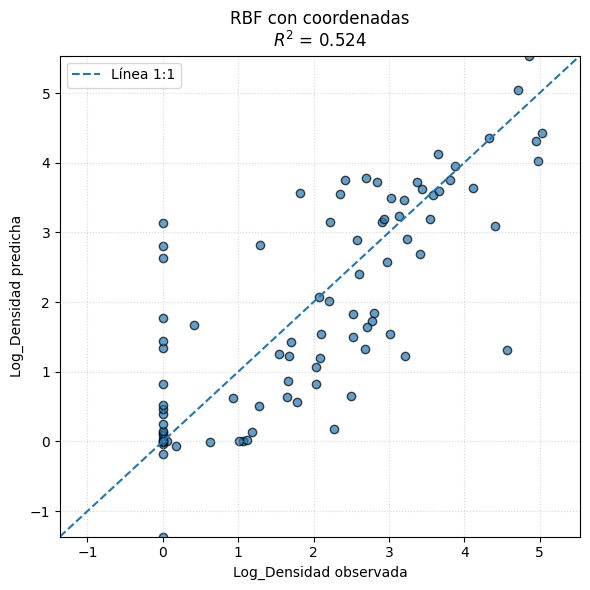

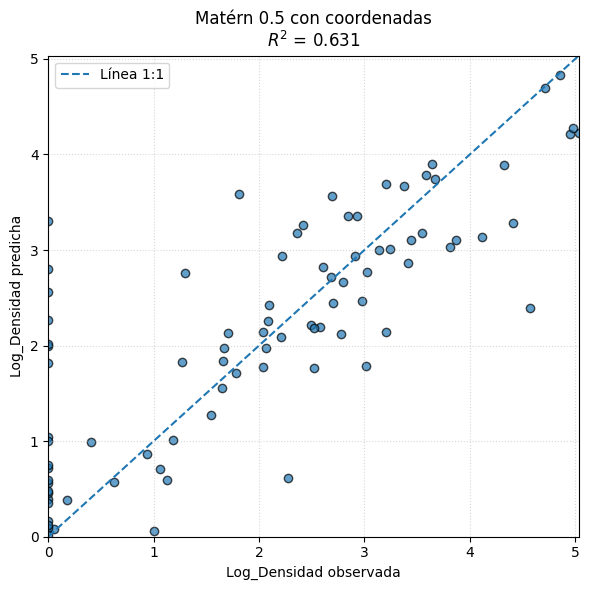

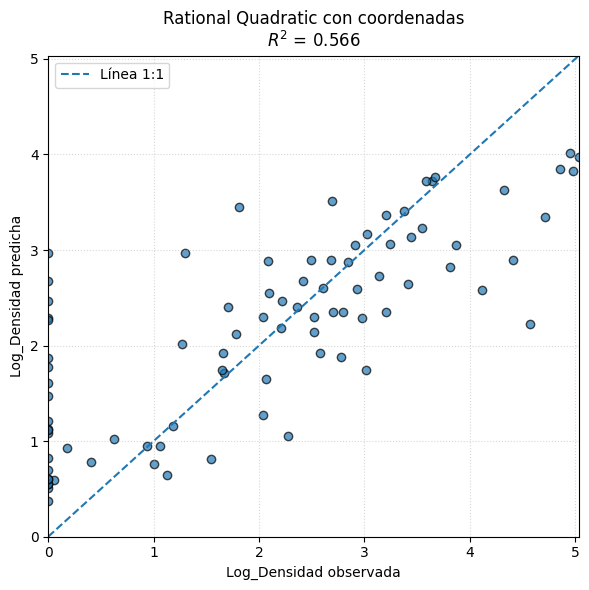

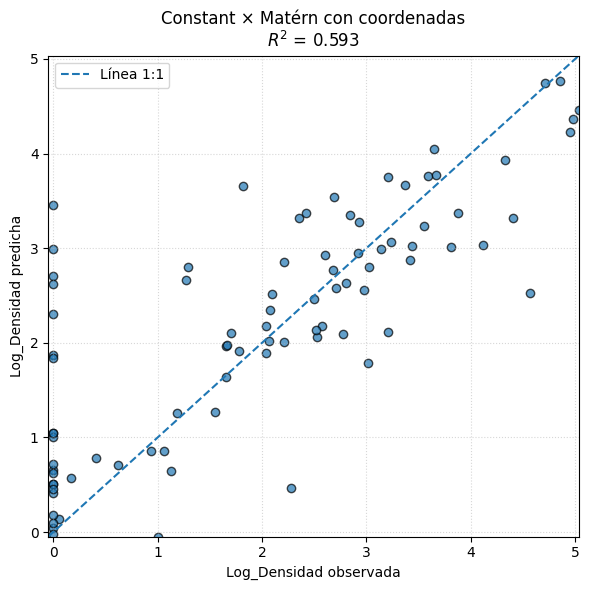

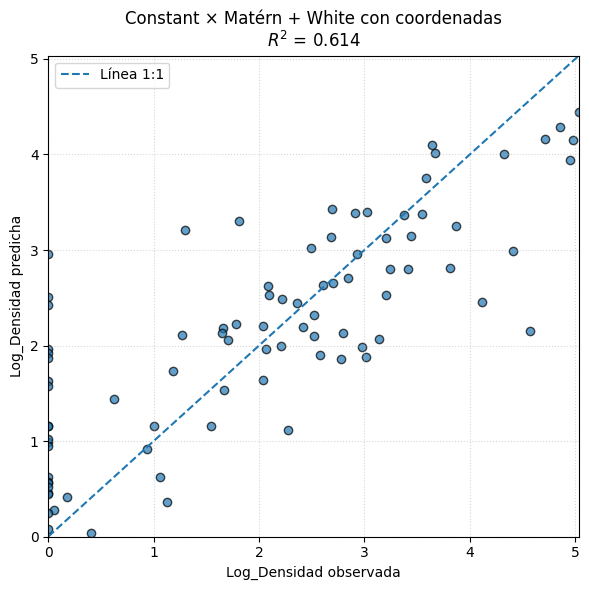

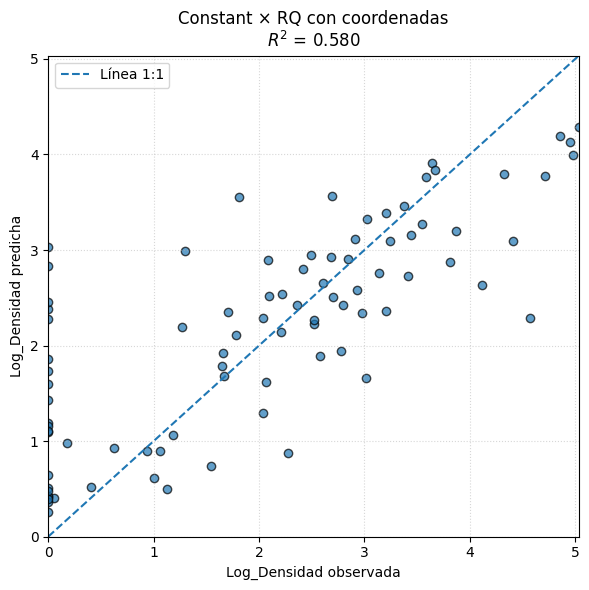

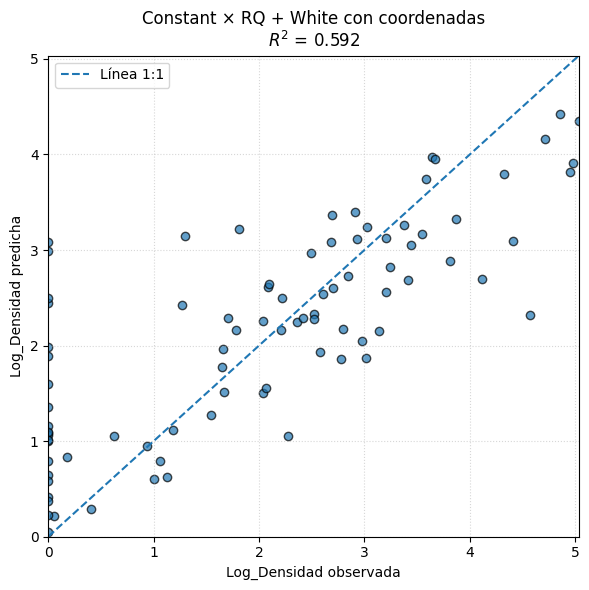

In [18]:
for nombre_kernel, modelo in modelose.items():

    yt_pred = modelo.predict(Xt_test_std)

    r2 = r2_score(yt_test, yt_pred)

    limite_min = min(yt_test.min(), yt_pred.min())
    limite_max = max(yt_test.max(), yt_pred.max())

    plt.figure(figsize=(6, 6))

    plt.scatter(
        yt_test,
        yt_pred,
        alpha=0.7,
        edgecolor="black"
    )

    plt.plot(
        [limite_min, limite_max],
        [limite_min, limite_max],
        linestyle="--",
        linewidth=1.5,
        label="Línea 1:1"
    )

    plt.xlabel("Log_Densidad observada")
    plt.ylabel("Log_Densidad predicha")
    plt.title(
        f"{nombre_kernel} con coordenadas\n"
        f"$R^2$ = {r2:.3f}"
    )

    plt.xlim(limite_min, limite_max)
    plt.ylim(limite_min, limite_max)

    plt.grid(
        linestyle=":",
        alpha=0.5
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

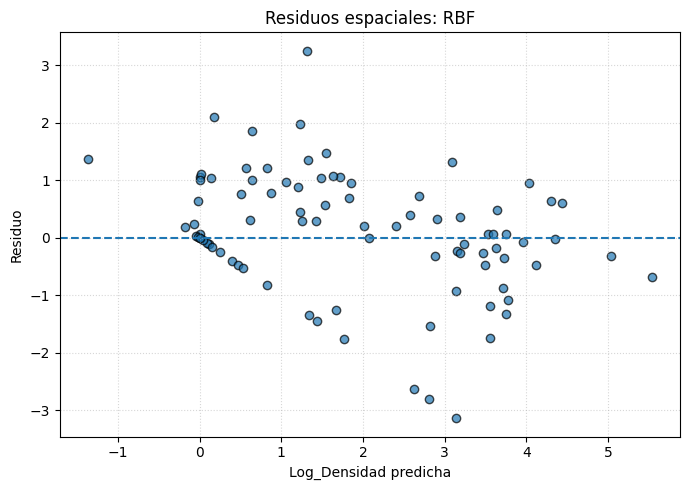

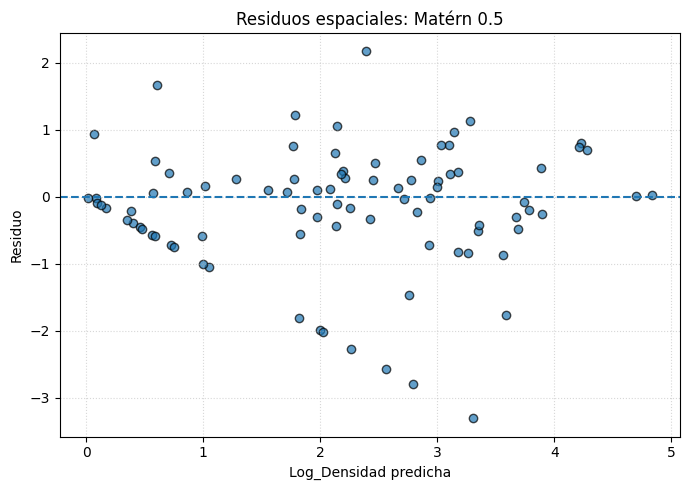

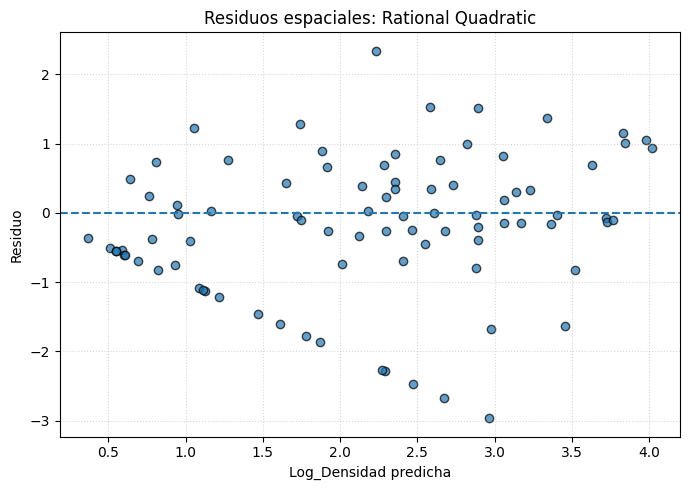

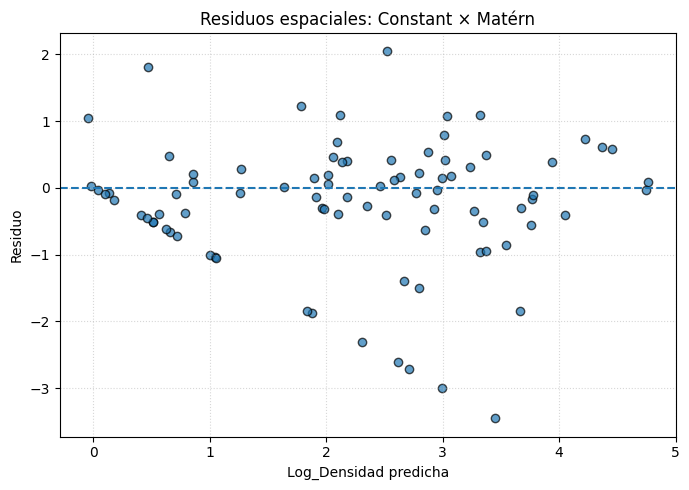

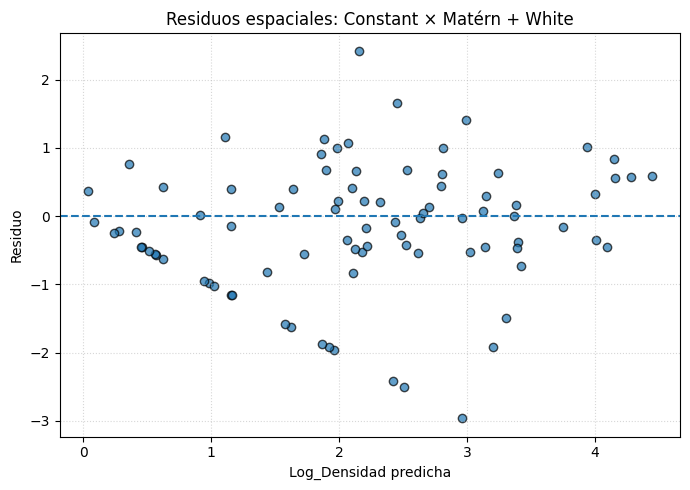

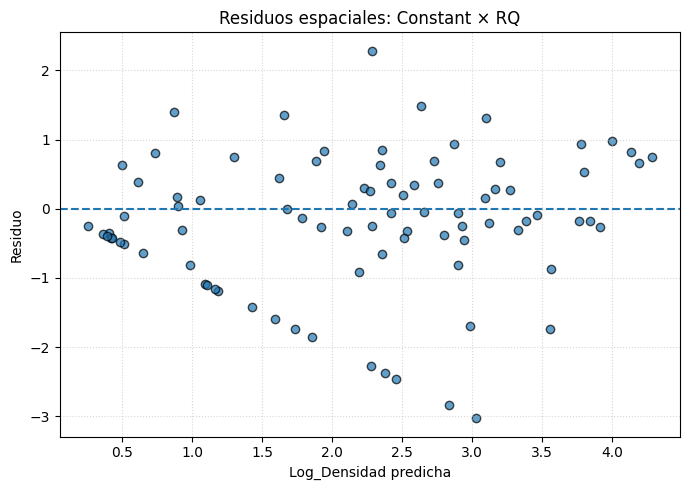

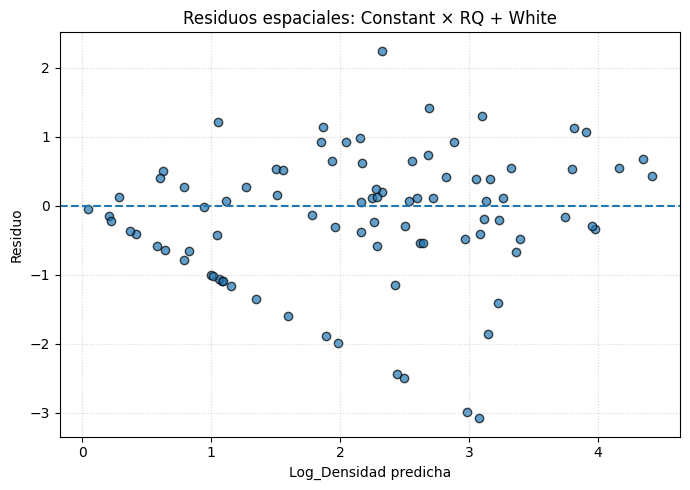

In [19]:
for nombre_kernel, modelo in modelose.items():

    yt_pred = modelo.predict(Xt_test_std)

    residuos = yt_test - yt_pred

    plt.figure(figsize=(7, 5))

    plt.scatter(
        yt_pred,
        residuos,
        alpha=0.7,
        edgecolor="black"
    )

    plt.axhline(
        y=0,
        linestyle="--",
        linewidth=1.5
    )

    plt.xlabel("Log_Densidad predicha")
    plt.ylabel("Residuo")
    plt.title(f"Residuos espaciales: {nombre_kernel}")

    plt.grid(
        linestyle=":",
        alpha=0.5
    )

    plt.tight_layout()
    plt.show()

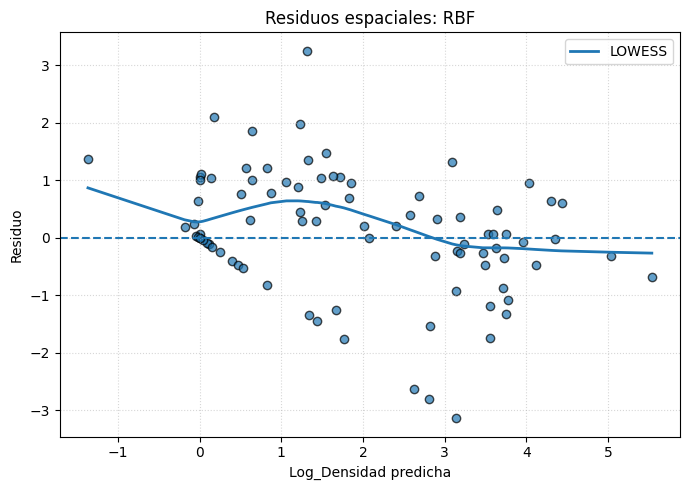

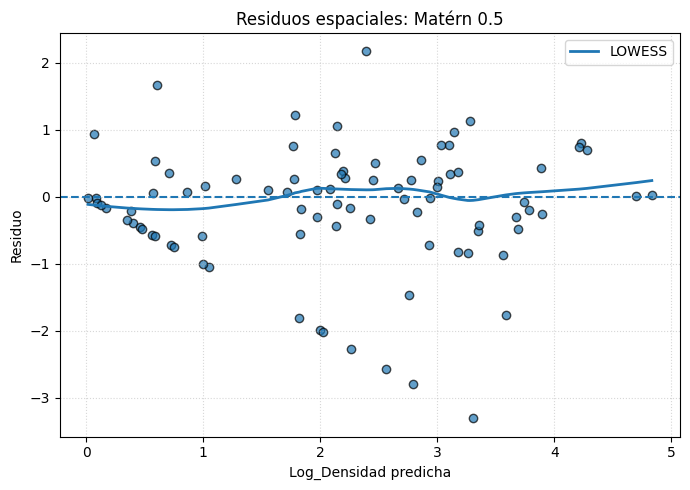

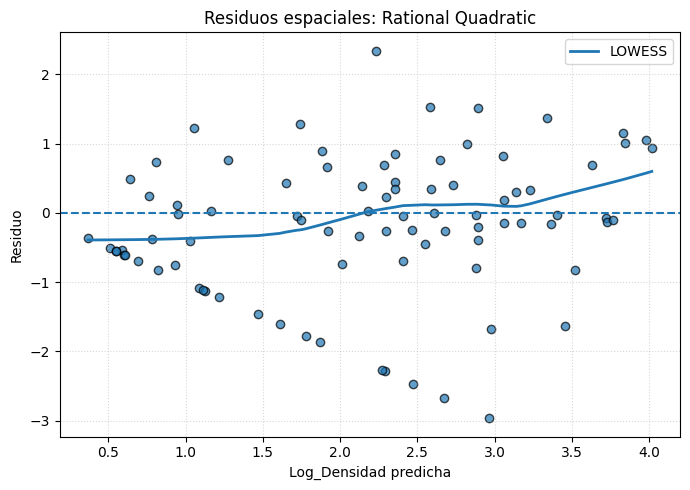

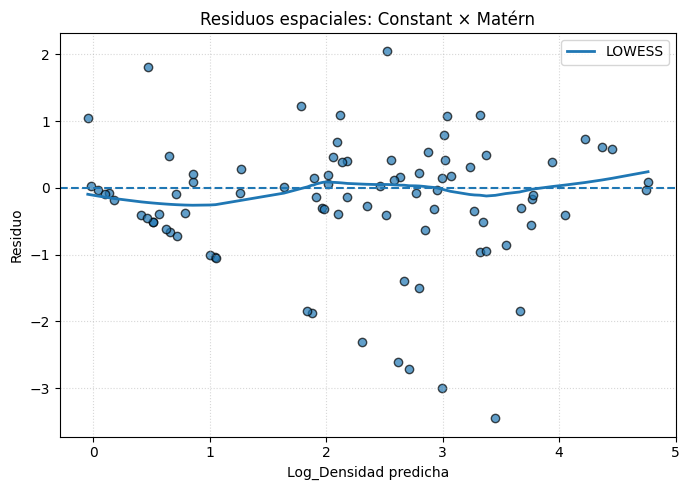

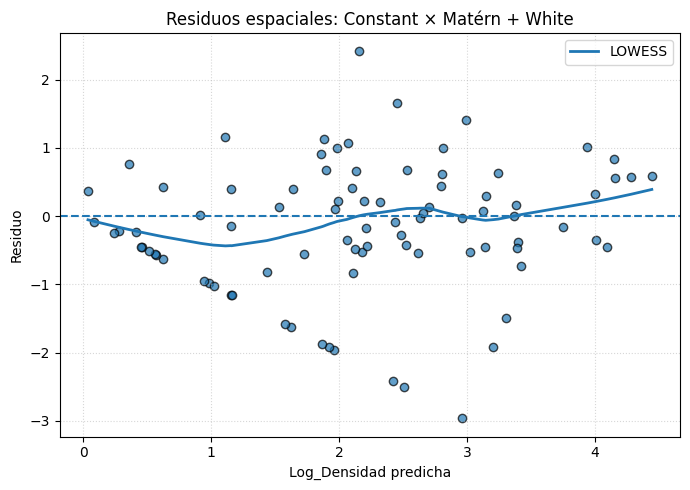

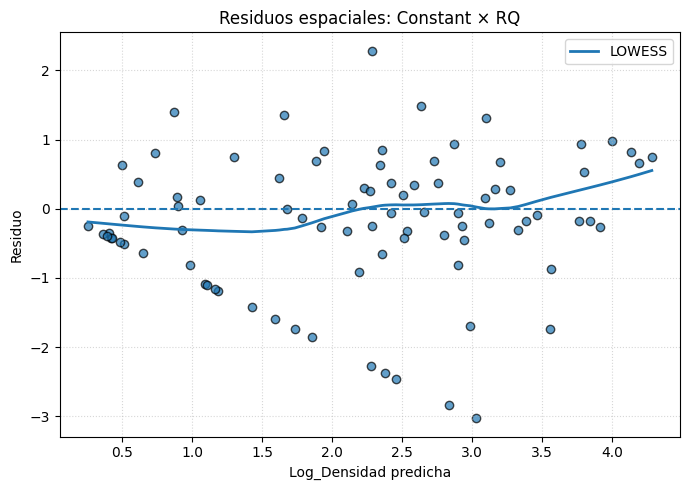

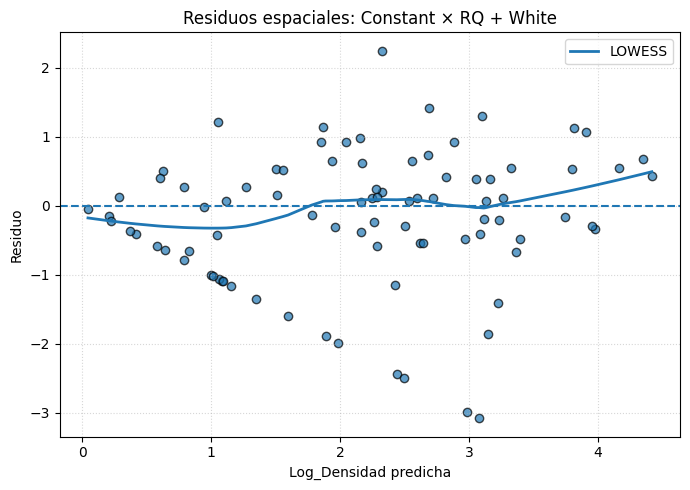

In [20]:
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

for nombre_kernel, modelo in modelose.items():

    yt_pred = modelo.predict(Xt_test_std)
    residuos = yt_test - yt_pred

    suavizado = lowess(
        residuos,
        yt_pred,
        frac=0.5,
        return_sorted=True
    )

    plt.figure(figsize=(7, 5))

    plt.scatter(
        yt_pred,
        residuos,
        alpha=0.7,
        edgecolor="black"
    )

    plt.plot(
        suavizado[:, 0],
        suavizado[:, 1],
        linewidth=2,
        label="LOWESS"
    )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1.5
    )

    plt.xlabel("Log_Densidad predicha")
    plt.ylabel("Residuo")
    plt.title(f"Residuos espaciales: {nombre_kernel}")
    plt.legend()
    plt.grid(linestyle=":", alpha=0.5)
    plt.tight_layout()
    plt.show()

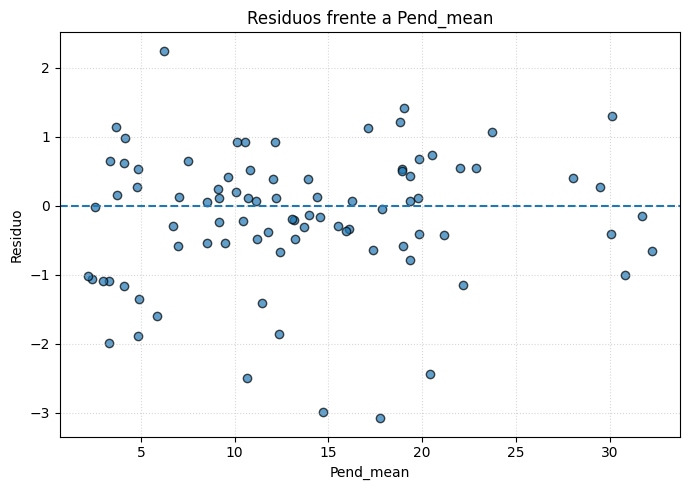

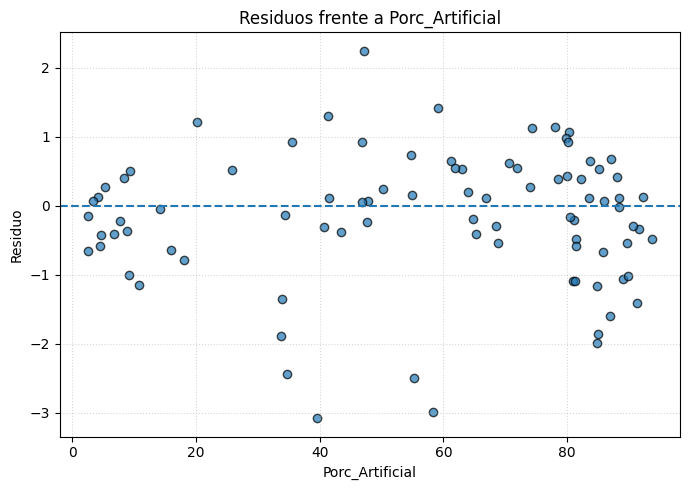

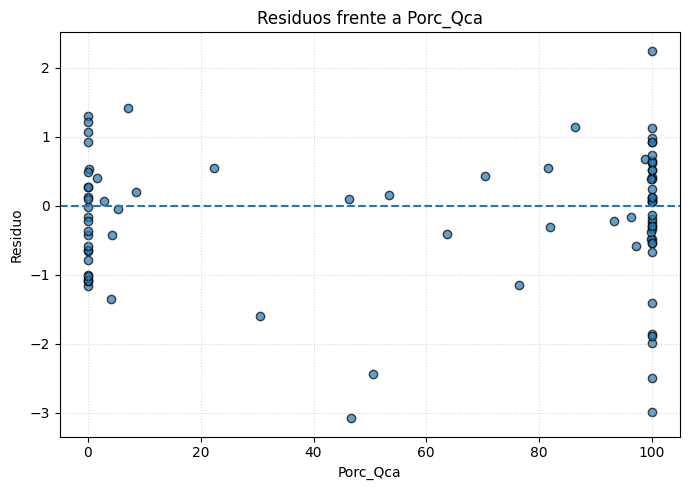

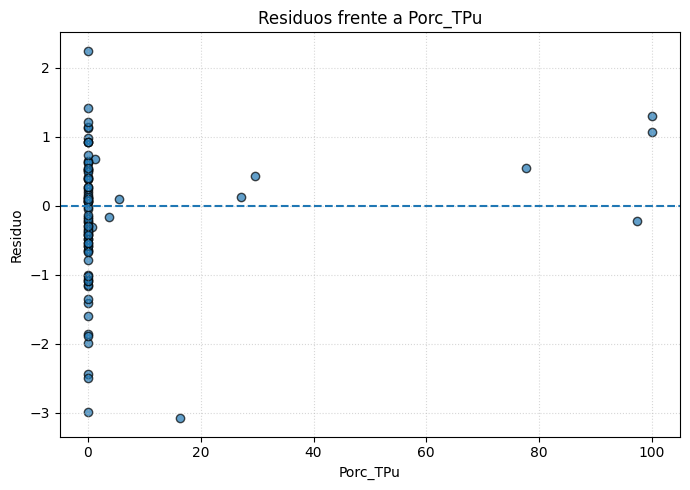

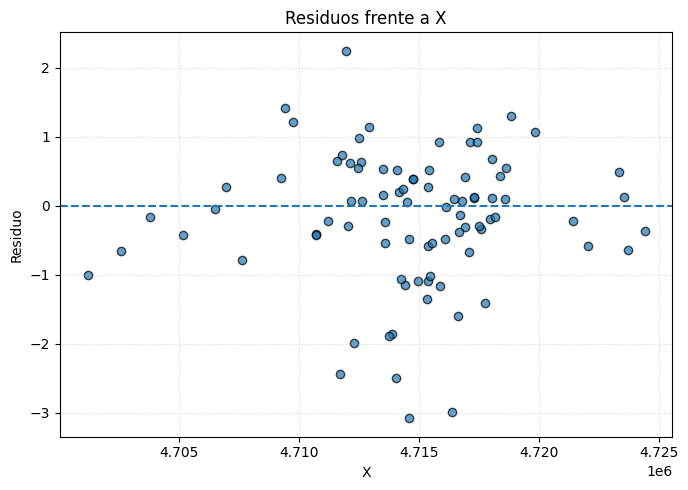

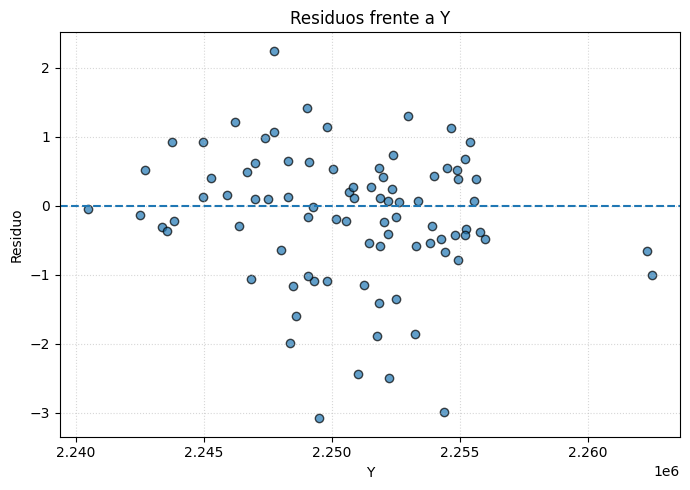

In [21]:
variables = [
    "Pend_mean",
    "Porc_Artificial",
    "Porc_Qca",
    "Porc_TPu",
    "X",
    "Y"
]

mejor_modelo = modelose["Constant × RQ + White"]

yt_pred = mejor_modelo.predict(Xt_test_std)
residuos = yt_test - yt_pred

for i, variable in enumerate(variables):

    plt.figure(figsize=(7, 5))

    plt.scatter(
        Xt_test[:, i],
        residuos,
        alpha=0.7,
        edgecolor="black"
    )

    plt.axhline(0, linestyle="--")

    plt.xlabel(variable)
    plt.ylabel("Residuo")
    plt.title(f"Residuos frente a {variable}")

    plt.grid(linestyle=":", alpha=0.5)
    plt.tight_layout()
    plt.show()

In [24]:
X_modelo = gdf[variablest]
modelo_gp = modelose["Constant × RQ + White"]

X_modelo = X_modelo.to_numpy()

X_std = escaladore.transform(X_modelo)

media_gp, std_gp = modelo_gp.predict(
    X_std,
    return_std=True
)

gdf["Media_GP"] = media_gp
gdf["Std_GP"] = std_gp
gdf["Var_GP"] = std_gp**2

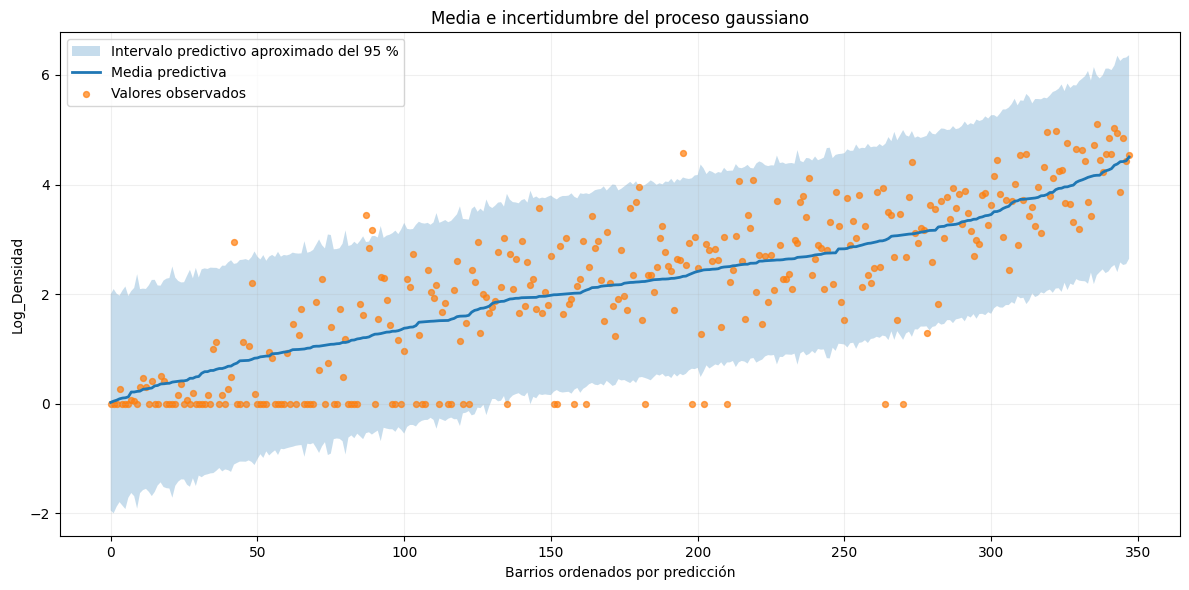

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

grafica = pd.DataFrame({
    "Observado": gdf["Log_Densidad"].to_numpy(),
    "Media": media_gp,
    "Std": std_gp
}).sort_values("Media").reset_index(drop=True)

grafica["Inferior"] = grafica["Media"] - 1.96 * grafica["Std"]
grafica["Superior"] = grafica["Media"] + 1.96 * grafica["Std"]

x = np.arange(len(grafica))

plt.figure(figsize=(12, 6))

plt.fill_between(
    x,
    grafica["Inferior"],
    grafica["Superior"],
    alpha=0.25,
    label="Intervalo predictivo aproximado del 95 %"
)

plt.plot(
    x,
    grafica["Media"],
    linewidth=2,
    label="Media predictiva"
)

plt.scatter(
    x,
    grafica["Observado"],
    s=18,
    alpha=0.7,
    label="Valores observados"
)

plt.xlabel("Barrios ordenados por predicción")
plt.ylabel("Log_Densidad")
plt.title("Media e incertidumbre del proceso gaussiano")
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

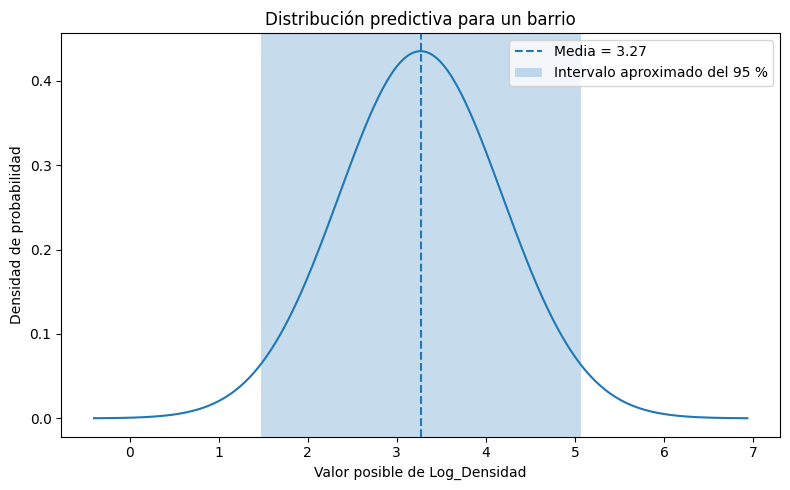

In [26]:
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

i = 10  # índice del barrio que quieres mostrar

mu = media_gp[i]
sigma = std_gp[i]

valores = np.linspace(
    mu - 4 * sigma,
    mu + 4 * sigma,
    300
)

densidad = norm.pdf(
    valores,
    loc=mu,
    scale=sigma
)

plt.figure(figsize=(8, 5))

plt.plot(valores, densidad)
plt.axvline(
    mu,
    linestyle="--",
    label=f"Media = {mu:.2f}"
)

plt.axvspan(
    mu - 1.96 * sigma,
    mu + 1.96 * sigma,
    alpha=0.25,
    label="Intervalo aproximado del 95 %"
)

plt.xlabel("Valor posible de Log_Densidad")
plt.ylabel("Densidad de probabilidad")
plt.title("Distribución predictiva para un barrio")
plt.legend()

plt.tight_layout()
plt.show()

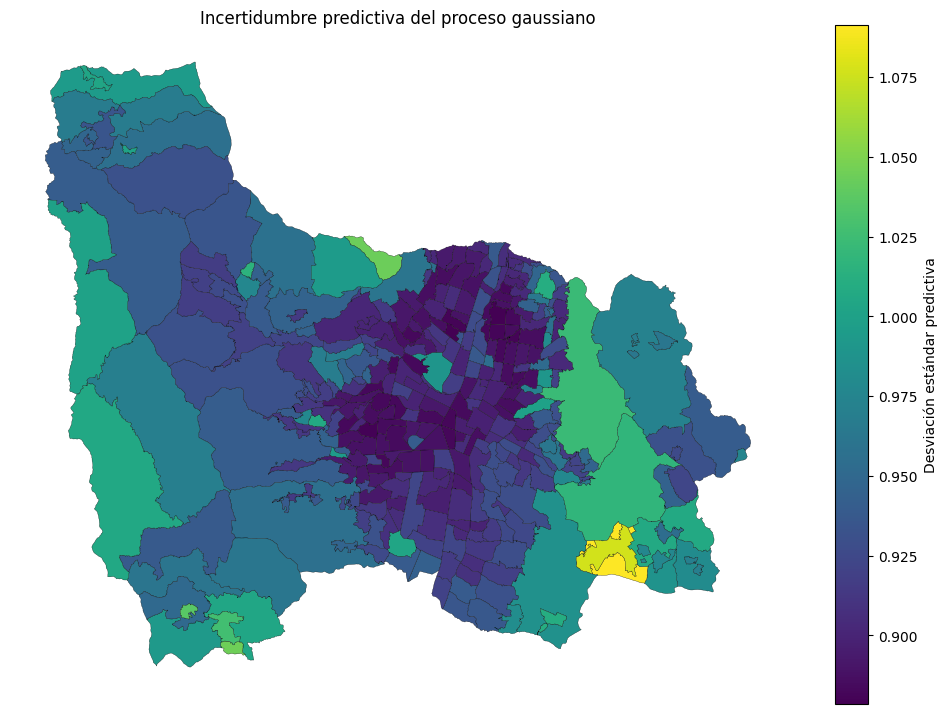

In [27]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    column="Std_GP",
    cmap="viridis",
    legend=True,
    edgecolor="black",
    linewidth=0.2,
    ax=ax,
    legend_kwds={
        "label": "Desviación estándar predictiva",
        "shrink": 0.7
    }
)

ax.set_title("Incertidumbre predictiva del proceso gaussiano")
ax.set_axis_off()

plt.tight_layout()
plt.show()

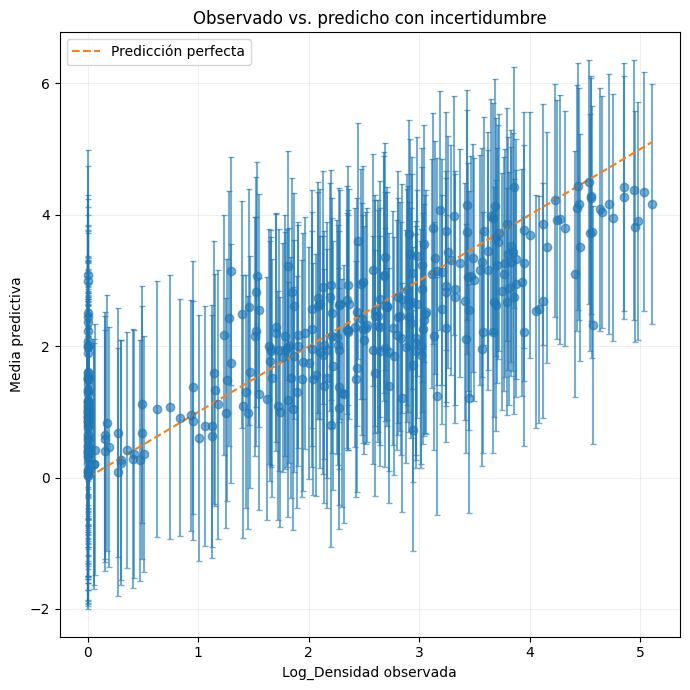

In [28]:
plt.figure(figsize=(7, 7))

plt.errorbar(
    gdf["Log_Densidad"],
    media_gp,
    yerr=1.96 * std_gp,
    fmt="o",
    alpha=0.6,
    capsize=2
)

limites = [
    min(gdf["Log_Densidad"].min(), media_gp.min()),
    max(gdf["Log_Densidad"].max(), media_gp.max())
]

plt.plot(
    limites,
    limites,
    linestyle="--",
    label="Predicción perfecta"
)

plt.xlabel("Log_Densidad observada")
plt.ylabel("Media predictiva")
plt.title("Observado vs. predicho con incertidumbre")
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

##Mapas

####RQ compuesto

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Variables utilizadas por el modelo espacial
variablest = [
    "Pend_mean",
    "Porc_Artificial",
    "Porc_Qca",
    "Porc_TPu",
    "X",
    "Y"
]

# Seleccionar el modelo espacial
modelo_gp = modelose["Constant × RQ + White"]

# Filtrar barrios con información completa
mascara = gdf[variablest].notna().all(axis=1)

# Matriz de variables para todos los barrios
X_mapa = gdf.loc[mascara, variablest].to_numpy()

# Estandarizar con el mismo escalador usado en el entrenamiento
X_mapa_std = escaladore.transform(X_mapa)

# Predicción media e incertidumbre
prediccion, incertidumbre = modelo_gp.predict(
    X_mapa_std,
    return_std=True
)

# Crear columnas en el GeoDataFrame
gdf["Pred_Log_Densidad"] = np.nan
gdf["Incertidumbre_GP"] = np.nan

gdf.loc[mascara, "Pred_Log_Densidad"] = prediccion
gdf.loc[mascara, "Incertidumbre_GP"] = incertidumbre

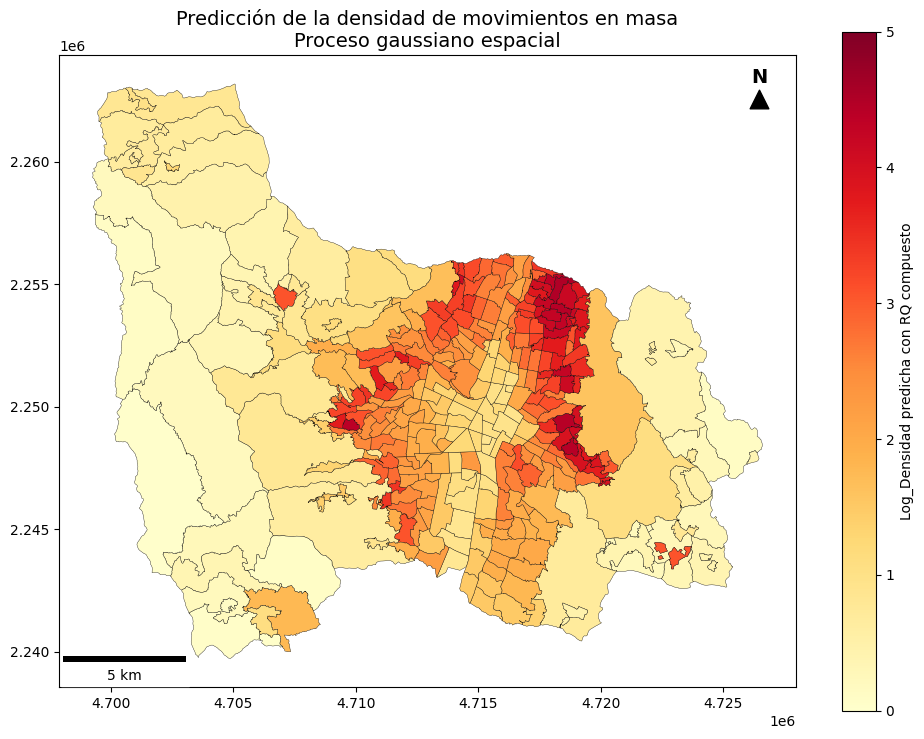

In [30]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    column="Pred_Log_Densidad",
    ax=ax,
    cmap="YlOrRd",
    vmin=0,
    vmax=5,
    legend=True,
    edgecolor="black",
    linewidth=0.25,
    missing_kwds={
        "color": "lightgrey",
        "label": "Sin información"},
    legend_kwds={
        "label": "Log_Densidad predicha con RQ compuesto",
        "shrink": 0.70})

scalebar = ScaleBar(
    dx=1,
    units="m",
    dimension="si-length",

    fixed_value=5,
    fixed_units="km",

    location="lower left")

ax.scatter(
    0.95,
    0.93,
    marker="^",
    s=180,
    color="black",
    transform=ax.transAxes,
    clip_on=False,
    zorder=10)

ax.text(
    0.95,
    0.95,
    "N",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=14,
    fontweight="bold")

ax.add_artist(scalebar)
ax.set_title(
    "Predicción de la densidad de movimientos en masa\n"
    "Proceso gaussiano espacial",
    fontsize=14)

plt.tight_layout()
plt.show()

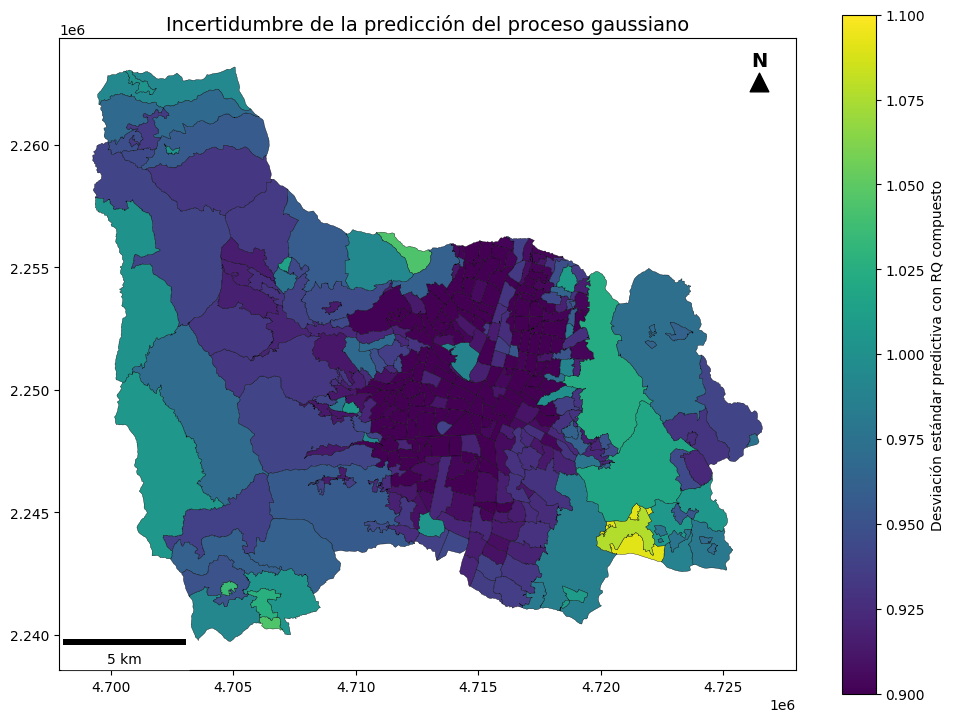

In [31]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    column="Incertidumbre_GP",
    ax=ax,
    cmap="viridis",
    vmin=0.9,
    vmax=1.1,
    legend=True,
    edgecolor="black",
    linewidth=0.25,
    missing_kwds={
        "color": "lightgrey",
        "label": "Sin información"},
    legend_kwds={
        "label": "Desviación estándar predictiva con RQ compuesto",
        "shrink": 0.70})

scalebar = ScaleBar(
    dx=1,
    units="m",
    dimension="si-length",

    fixed_value=5,
    fixed_units="km",

    location="lower left")

ax.scatter(
    0.95,
    0.93,
    marker="^",
    s=180,
    color="black",
    transform=ax.transAxes,
    clip_on=False,
    zorder=10)

ax.text(
    0.95,
    0.95,
    "N",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=14,
    fontweight="bold")

ax.add_artist(scalebar)
ax.set_title(
    "Incertidumbre de la predicción del proceso gaussiano",
    fontsize=14)

plt.tight_layout()
plt.show()

####Matern compuesto

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Variables utilizadas por el modelo espacial
variablest = [
    "Pend_mean",
    "Porc_Artificial",
    "Porc_Qca",
    "Porc_TPu",
    "X",
    "Y"
]

# Seleccionar el modelo espacial
modelo_gp = modelose["Constant × Matérn + White"]

# Filtrar barrios con información completa
mascara = gdf[variablest].notna().all(axis=1)

# Matriz de variables para todos los barrios
X_mapa = gdf.loc[mascara, variablest].to_numpy()

# Estandarizar con el mismo escalador usado en el entrenamiento
X_mapa_std = escaladore.transform(X_mapa)

# Predicción media e incertidumbre
prediccion, incertidumbre = modelo_gp.predict(
    X_mapa_std,
    return_std=True)

# Crear columnas en el GeoDataFrame
gdf["Pred_Log_Densidadmatern"] = np.nan
gdf["Incertidumbre_GPmatern"] = np.nan

gdf.loc[mascara, "Pred_Log_Densidadmatern"] = prediccion
gdf.loc[mascara, "Incertidumbre_GPmatern"] = incertidumbre

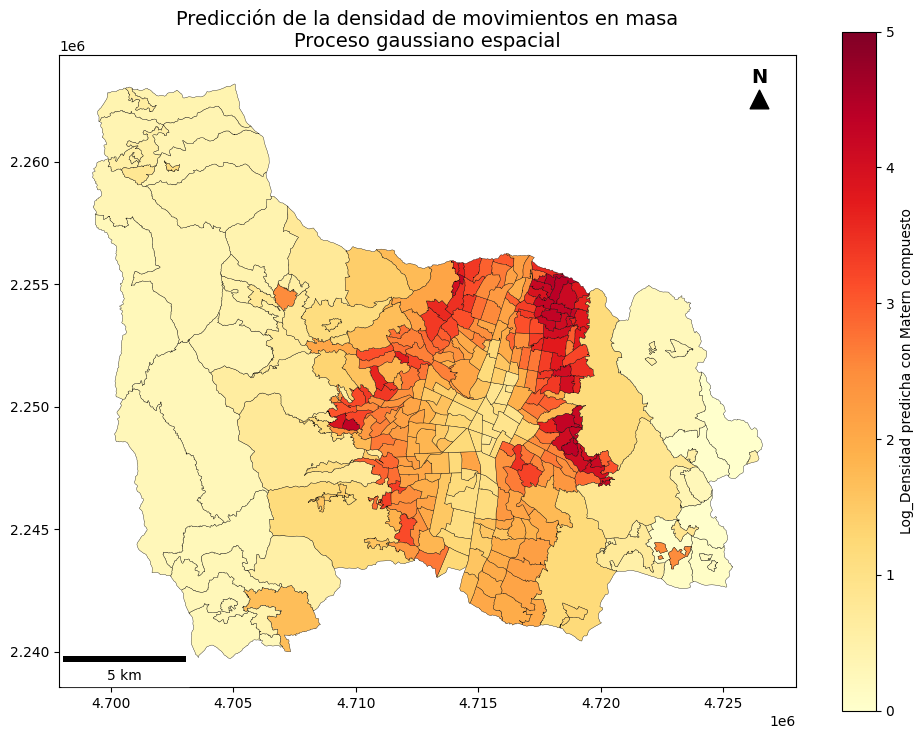

In [33]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    column="Pred_Log_Densidadmatern",
    ax=ax,
    cmap="YlOrRd",
    vmin=0,
    vmax=5,
    legend=True,
    edgecolor="black",
    linewidth=0.25,
    missing_kwds={
        "color": "lightgrey",
        "label": "Sin información"},
    legend_kwds={
        "label": "Log_Densidad predicha con Matern compuesto",
        "shrink": 0.70})

scalebar = ScaleBar(
    dx=1,
    units="m",
    dimension="si-length",

    fixed_value=5,
    fixed_units="km",

    location="lower left")

ax.scatter(
    0.95,
    0.93,
    marker="^",
    s=180,
    color="black",
    transform=ax.transAxes,
    clip_on=False,
    zorder=10)

ax.text(
    0.95,
    0.95,
    "N",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=14,
    fontweight="bold")

ax.add_artist(scalebar)
ax.set_title(
    "Predicción de la densidad de movimientos en masa\n"
    "Proceso gaussiano espacial",
    fontsize=14)

plt.tight_layout()
plt.show()

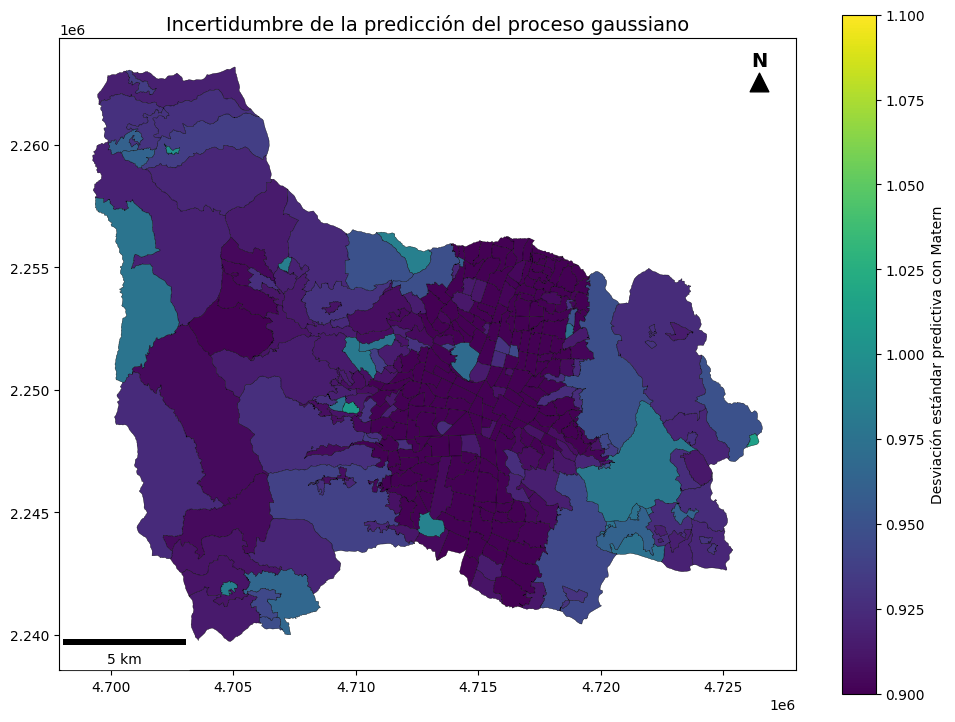

In [34]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    column="Incertidumbre_GPmatern",
    ax=ax,
    cmap="viridis",
    vmin=0.9,
    vmax=1.1,
    legend=True,
    edgecolor="black",
    linewidth=0.25,
    missing_kwds={
        "color": "lightgrey",
        "label": "Sin información"
    },
    legend_kwds={
        "label": "Desviación estándar predictiva con Matern",
        "shrink": 0.70})

scalebar = ScaleBar(
    dx=1,
    units="m",
    dimension="si-length",

    fixed_value=5,
    fixed_units="km",

    location="lower left")

ax.scatter(
    0.95,
    0.93,
    marker="^",
    s=180,
    color="black",
    transform=ax.transAxes,
    clip_on=False,
    zorder=10)

ax.text(
    0.95,
    0.95,
    "N",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=14,
    fontweight="bold")

ax.add_artist(scalebar)
ax.set_title(
    "Incertidumbre de la predicción del proceso gaussiano",
    fontsize=14)


plt.tight_layout()
plt.show()